Imports all libraries needed for the analysis and reads the cleaned survey CSV. The two-row Qualtrics header requires `header=[0,1]`; the first data row (containing question text) is then dropped to leave only responses.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, silhouette_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler

survey_data = pd.read_csv("Cleaned_BookstoreSurvey.csv", header=[0, 1])
survey_data = survey_data.drop(survey_data.index[0]).reset_index(drop=True)
print(survey_data.shape)
print(survey_data.head(3))

(48, 26)
                                   Q1  \
  What is your affiliation with CWRU?   
0               Undergraduate student   
1               Undergraduate student   
2               Undergraduate student   

                                                            Q4  \
  Have you ever browsed the CWRU bookstore (in-person/online)?   
0                                                yes             
1                                                yes             
2                                                yes             

                                                                   Q6  \
  Have you ever purchased from the CWRU bookstore (in-person/online)?   
0                                                yes                    
1                                                yes                    
2                                                yes                    

                                                                 Q7  \
  What type of cl

***Feature Engineering — Encoding Ordinal & Categorical Variables***

Converts each survey question's text responses into numbers. Likert-scale items become ordinal scores (1–4 for likelihood, 1–6 for spending), yes/no questions become binary flags, and year-in-school is ranked 1–4. Rows with any missing value are dropped, leaving a fully numeric modeling dataset.

In [2]:
q26_col = ("Q26", "How likely are you to purchase clothing from the CWRU bookstore next semester?")
q18_col = ("Q18", "How likely are you to purchase apparel after seeing an online advertisement?")
q21_col = ("Q21", "How likely are you to purchase bookstore clothing after seeing an in-person advertisement?")
q6_col  = ("Q6",  "Have you ever purchased from the CWRU bookstore (in-person/online)?")
q4_col  = ("Q4",  "Have you ever browsed the CWRU bookstore (in-person/online)?")
q8_col  = ("Q8",  "What is the most important factor you consider when deciding to purchase new apparel?")
q23_col = ("Q23", "In the last 3 months, what is the most you have spent on a single non-essential clothing item?")
q24_col = ("Q24", "On average how much do you spend on a single item of clothing during a typical shopping trip/purchase?")
q2_col  = ("Q2",  "What is your current year in school?")
q3_col  = ("Q3",  "What is your gender?")

likelihood_map = {
    "1- Very unlikely": 1, "1-  Very unlikely": 1,
    "2- Unlikely": 2,      "2-  Unlikely": 2,
    "3- Likely": 3,        "3-  Likely": 3,
    "4- Very likely": 4,   "4-  Very likely": 4,
}

spending_map = {"<$10": 1, "$10 - $20": 2, "$20 - $30": 3, "$30 - $40": 4, "$40 - $50": 5, "$50+": 6}
year_map     = {"Freshman": 1, "Sophomore": 2, "Junior": 3, "Senior": 4}

model_df = pd.DataFrame()
model_df["purchase_likelihood"]    = survey_data[q26_col].map(likelihood_map)
model_df["online_ad_likelihood"]   = survey_data[q18_col].map(likelihood_map)
model_df["inperson_ad_likelihood"] = survey_data[q21_col].map(likelihood_map)
model_df["has_purchased"]          = (survey_data[q6_col].str.strip().str.lower() == "yes").astype(int)
model_df["has_browsed"]            = (survey_data[q4_col].str.strip().str.lower() == "yes").astype(int)
model_df["price_priority"]         = (survey_data[q8_col].str.strip() == "Price").astype(int)
model_df["max_spend_score"]        = survey_data[q23_col].str.strip().map(spending_map)
model_df["avg_spend_score"]        = survey_data[q24_col].str.strip().map(spending_map)
model_df["year_in_school"]         = survey_data[q2_col].str.strip().map(year_map)
model_df["is_female"]              = (survey_data[q3_col].str.strip() == "Female").astype(int)

model_df = model_df.dropna().reset_index(drop=True)
print(f"Modeling dataset: {model_df.shape[0]} rows, {model_df.shape[1]} columns")
print(model_df.describe())

Modeling dataset: 48 rows, 10 columns
       purchase_likelihood  online_ad_likelihood  inperson_ad_likelihood  \
count            48.000000             48.000000               48.000000   
mean              2.041667              1.791667                1.979167   
std               0.874176              0.713348                0.668106   
min               1.000000              1.000000                1.000000   
25%               1.000000              1.000000                2.000000   
50%               2.000000              2.000000                2.000000   
75%               3.000000              2.000000                2.000000   
max               4.000000              4.000000                4.000000   

       has_purchased  has_browsed  price_priority  max_spend_score  \
count      48.000000    48.000000       48.000000        48.000000   
mean        0.666667     0.750000        0.562500         4.020833   
std         0.476393     0.437595        0.501328         1.768394 

***Model 1 — Logistic Regression for Purchase Intent***

Analytical question 1: Which students are most likely to buy CWRU bookstore clothing next semester? This model connects to the bookstore's MDPs around increasing sales, setting promotional priorities, and identifying which factors most strongly influence purchase intent. Logistic regression is appropriate because the outcome is binary — likely to purchase (Q26 = 3 or 4) versus unlikely to purchase (Q26 = 1 or 2) — and the coefficients can be translated into business language. With only 48 survey responses, this should be treated as a directional marketing model rather than a high-stakes production predictor.

In [3]:
model_df["will_purchase"] = (model_df["purchase_likelihood"] >= 3).astype(int)
print("Target definition: will_purchase = 1 if Q26 is 3 or 4, otherwise 0")
print("Class distribution:\n", model_df["will_purchase"].value_counts().sort_index())

features = ["online_ad_likelihood", "inperson_ad_likelihood", "has_purchased",
            "has_browsed", "price_priority", "max_spend_score", "avg_spend_score",
            "year_in_school", "is_female"]

X = model_df[features]
y = model_df["will_purchase"]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("\nPredictors used in the logistic model:")
for feature in features:
    print(f"- {feature}")

Target definition: will_purchase = 1 if Q26 is 3 or 4, otherwise 0
Class distribution:
 will_purchase
0    33
1    15
Name: count, dtype: int64

Predictors used in the logistic model:
- online_ad_likelihood
- inperson_ad_likelihood
- has_purchased
- has_browsed
- price_priority
- max_spend_score
- avg_spend_score
- year_in_school
- is_female


The model is tuned with 5-fold stratified cross-validation, then evaluated using cross-validated predictions rather than in-sample training accuracy. This makes the reported confusion matrix, precision, recall, and F1-score more defensible under the project guidelines. After evaluation, the best logistic regression model is refit on the full dataset so its coefficients and odds ratios can be interpreted as directional marketing insights.

In [4]:
param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "solver": ["liblinear", "lbfgs"],
}

grid_search = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid,
    cv=cv,
    scoring="accuracy",
    refit=True
)
grid_search.fit(X, y)

best_log_reg = grid_search.best_estimator_
cv_pred = cross_val_predict(best_log_reg, X, y, cv=cv)
cv_accuracy = accuracy_score(y, cv_pred)
cm = confusion_matrix(y, cv_pred)

print(f"Best parameters: {grid_search.best_params_}")
print(f"5-fold CV accuracy: {cv_accuracy:.3f}\n")
print("Cross-validated classification report:")
print(classification_report(y, cv_pred, target_names=["Unlikely (0)", "Likely (1)"]))

best_log_reg.fit(X, y)
coef_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": best_log_reg.coef_[0],
    "Odds Ratio": np.exp(best_log_reg.coef_[0])
}).sort_values("Coefficient", ascending=False)
print("Coefficient table (full-sample refit for interpretation):")
print(coef_df.to_string(index=False))

print("\nBusiness interpretation:")
print(f"- Strongest positive signal: {coef_df.iloc[0]['Feature']} (odds ratio = {coef_df.iloc[0]['Odds Ratio']:.2f})")
print(f"- Strongest negative signal: {coef_df.iloc[-1]['Feature']} (odds ratio = {coef_df.iloc[-1]['Odds Ratio']:.2f})")
print("- Positive coefficients indicate characteristics associated with higher purchase intent.")
print("- Negative coefficients indicate characteristics associated with lower purchase intent.")

Best parameters: {'C': 100, 'solver': 'liblinear'}
5-fold CV accuracy: 0.688

Cross-validated classification report:
              precision    recall  f1-score   support

Unlikely (0)       0.76      0.79      0.78        33
  Likely (1)       0.50      0.47      0.48        15

    accuracy                           0.69        48
   macro avg       0.63      0.63      0.63        48
weighted avg       0.68      0.69      0.68        48

Coefficient table (full-sample refit for interpretation):
               Feature  Coefficient  Odds Ratio
           has_browsed     4.038671   56.750867
  online_ad_likelihood     0.926808    2.526431
inperson_ad_likelihood     0.882429    2.416763
       max_spend_score    -0.095439    0.908974
       avg_spend_score    -0.238755    0.787608
             is_female    -0.649037    0.522549
        year_in_school    -1.115568    0.327729
        price_priority    -1.661090    0.189932
         has_purchased    -3.062081    0.046790

Business interpre

The confusion matrix below is based on cross-validated predictions, not training-set predictions. This shows how well the model generalizes within the sample, while the coefficient chart highlights which marketing-related inputs are most associated with purchase intent.

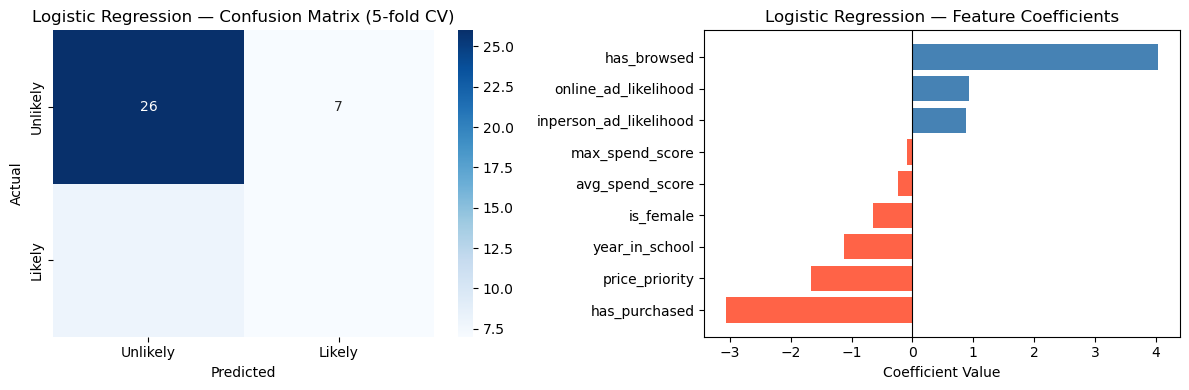

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["Unlikely", "Likely"],
            yticklabels=["Unlikely", "Likely"])
axes[0].set_title("Logistic Regression — Confusion Matrix (5-fold CV)")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

coef_df_sorted = coef_df.sort_values("Coefficient")
colors = ["tomato" if c < 0 else "steelblue" for c in coef_df_sorted["Coefficient"]]
axes[1].barh(coef_df_sorted["Feature"], coef_df_sorted["Coefficient"], color=colors)
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title("Logistic Regression — Feature Coefficients")
axes[1].set_xlabel("Coefficient Value")

plt.tight_layout()
plt.show()

***Model 2 — K-Means Segmentation for Marketing Strategy***

Analytical question 2: Are there distinct student segments with different purchase intent, ad responsiveness, and spending behavior? This model supports the bookstore's MDPs around targeting, pricing, and promotion strategy. K-means is appropriate here because the goal is to identify actionable customer segments rather than predict a single outcome. The clustering inputs are standardized first so the 1-to-6 spending variables do not dominate the 1-to-4 likelihood variables.

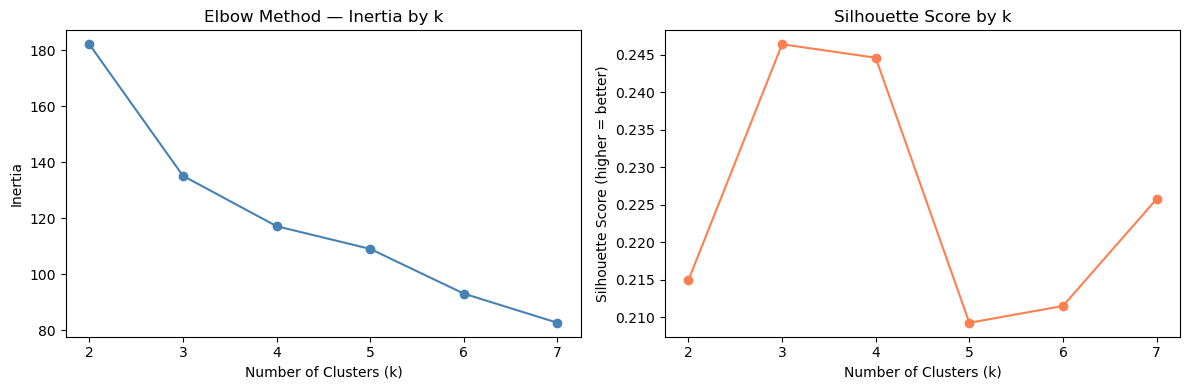

Silhouette scores by k:
- k = 2: 0.215
- k = 3: 0.246
- k = 4: 0.245
- k = 5: 0.209
- k = 6: 0.211
- k = 7: 0.226

Chosen number of segments (best k): 3  (score = 0.246)


In [6]:
cluster_features = ["purchase_likelihood", "online_ad_likelihood", "inperson_ad_likelihood",
                    "max_spend_score", "avg_spend_score"]
X_clust = model_df[cluster_features]
scaler = StandardScaler()
X_clust_scaled = scaler.fit_transform(X_clust)

inertias = []
silhouette_scores = []
k_range = range(2, 8)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_clust_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_clust_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(k_range, inertias, marker="o", color="steelblue")
axes[0].set_title("Elbow Method — Inertia by k")
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("Inertia")
axes[0].set_xticks(list(k_range))

axes[1].plot(k_range, silhouette_scores, marker="o", color="coral")
axes[1].set_title("Silhouette Score by k")
axes[1].set_xlabel("Number of Clusters (k)")
axes[1].set_ylabel("Silhouette Score (higher = better)")
axes[1].set_xticks(list(k_range))

plt.tight_layout()
plt.show()

best_k = list(k_range)[np.argmax(silhouette_scores)]
print("Silhouette scores by k:")
for k, score in zip(k_range, silhouette_scores):
    print(f"- k = {k}: {score:.3f}")
print(f"\nChosen number of segments (best k): {best_k}  (score = {max(silhouette_scores):.3f})")

The final clustering model is fit on the standardized variables, then each segment is profiled using the original-scale survey scores so the results remain interpretable. Each segment receives a plain-English label and a recommended business action tied to the marketing research problem.

In [7]:
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
model_df["cluster"] = kmeans.fit_predict(X_clust_scaled)

cluster_profile = model_df.groupby("cluster")[cluster_features + ["has_purchased"]].mean().round(2)
cluster_profile.index = [f"Segment {i}" for i in cluster_profile.index]
print("Cluster Profiles (mean values per segment):")
print(cluster_profile.to_string())

sample_means = cluster_profile[["purchase_likelihood", "online_ad_likelihood", "inperson_ad_likelihood", "avg_spend_score"]].mean()
segment_descriptions = {}

for seg in cluster_profile.index:
    row = cluster_profile.loc[seg]
    if row["purchase_likelihood"] >= sample_means["purchase_likelihood"] and row["avg_spend_score"] >= sample_means["avg_spend_score"]:
        label = "High-Intent, Higher-Spend"
        action = "Prioritize premium drops or limited-release apparel for this group."
    elif row[["online_ad_likelihood", "inperson_ad_likelihood"]].mean() >= sample_means[["online_ad_likelihood", "inperson_ad_likelihood"]].mean():
        label = "Ad-Responsive Segment"
        action = "Target this group with promotional campaigns, especially around discounts and new apparel announcements."
    else:
        label = "Low-Intent, Price-Sensitive"
        action = "Use discounts, giveaways, and simpler designs to reduce purchase barriers for this group."
    segment_descriptions[seg] = action
    cluster_profile.loc[seg, "Label"] = label
    cluster_profile.loc[seg, "Recommended Action"] = action

print("\nSegment labels and business implications:")
print(cluster_profile[["Label", "Recommended Action"]].to_string())

Cluster Profiles (mean values per segment):
           purchase_likelihood  online_ad_likelihood  inperson_ad_likelihood  max_spend_score  avg_spend_score  has_purchased
Segment 0                 3.00                  2.58                    2.50             3.33             2.75           0.42
Segment 1                 1.77                  1.31                    1.38             2.54             2.38           0.69
Segment 2                 1.70                  1.65                    2.04             5.22             4.48           0.78

Segment labels and business implications:
                                 Label                                                                                        Recommended Action
Segment 0        Ad-Responsive Segment  Target this group with promotional campaigns, especially around discounts and new apparel announcements.
Segment 1  Low-Intent, Price-Sensitive                 Use discounts, giveaways, and simpler designs to reduce purchase

The charts below visualize the segments and their sizes, and the printed notes summarize what each segment implies for the bookstore. A short limitations section is included because the survey is small, non-random, and based on stated purchase intent rather than observed buying behavior.

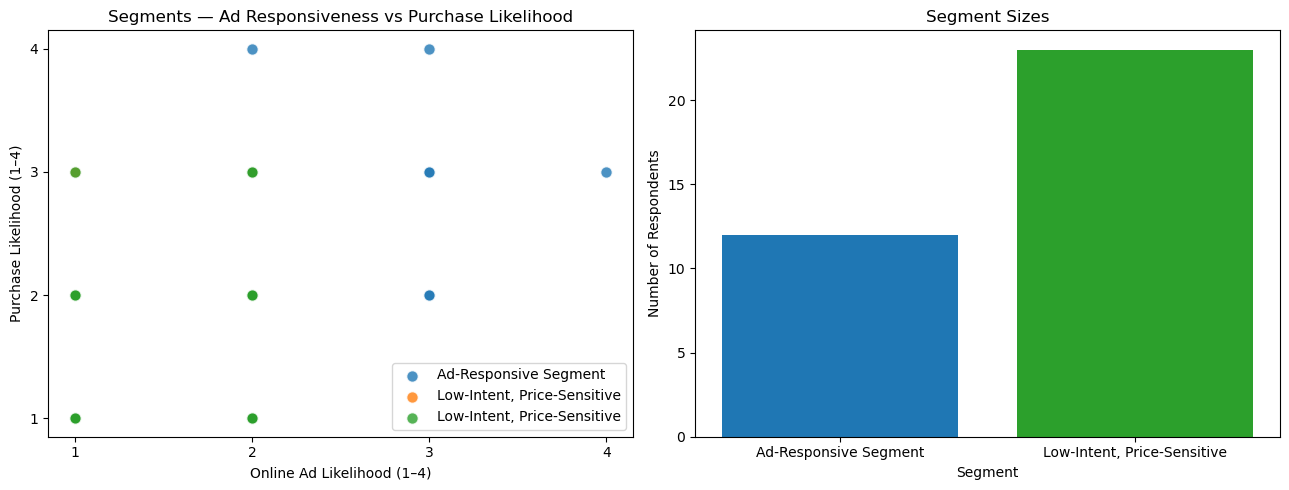


Limitations:
- The sample is small (48 responses), so the results should be treated as directional rather than definitive.
- The survey appears to be a convenience sample of CWRU students, not a random sample of the full bookstore market.
- The models use self-reported purchase intentions and attitudes, not observed transaction data.
- These results are best used to guide marketing decisions on targeting, pricing, and promotion rather than to make precise forecasts.


In [8]:
palette = sns.color_palette("tab10", n_colors=best_k)
colors_map = {i: palette[i] for i in range(best_k)}
segment_labels = cluster_profile["Label"].to_dict()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for seg, grp in model_df.groupby("cluster"):
    label = segment_labels.get(f"Segment {seg}", f"Segment {seg}")
    axes[0].scatter(grp["online_ad_likelihood"], grp["purchase_likelihood"],
                    label=label, color=colors_map[seg], alpha=0.8, edgecolors="white", s=70)
axes[0].set_title("Segments — Ad Responsiveness vs Purchase Likelihood")
axes[0].set_xlabel("Online Ad Likelihood (1–4)")
axes[0].set_ylabel("Purchase Likelihood (1–4)")
axes[0].legend()
axes[0].set_xticks([1, 2, 3, 4])
axes[0].set_yticks([1, 2, 3, 4])

cluster_sizes = model_df["cluster"].value_counts().sort_index()
bar_labels = [segment_labels.get(f"Segment {i}", f"Segment {i}") for i in cluster_sizes.index]
axes[1].bar(bar_labels, cluster_sizes.values, color=[colors_map[i] for i in cluster_sizes.index])
axes[1].set_title("Segment Sizes")
axes[1].set_xlabel("Segment")
axes[1].set_ylabel("Number of Respondents")

plt.tight_layout()
plt.show()

print("\nLimitations:")
print("- The sample is small (48 responses), so the results should be treated as directional rather than definitive.")
print("- The survey appears to be a convenience sample of CWRU students, not a random sample of the full bookstore market.")
print("- The models use self-reported purchase intentions and attitudes, not observed transaction data.")
print("- These results are best used to guide marketing decisions on targeting, pricing, and promotion rather than to make precise forecasts.")